# Counts and discrete targets

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/discrete_targets.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/discrete_targets.ipynb)

Every model in `lazy` predicts a density over the real line, while many
targets are counts that cannot go below zero, or scores that take only a
handful of integer values. In this tutorial, we predict hourly bike rentals
and wine quality scores, examine the predicted distributions near the floor
at zero and between the integers, and compute the probability of each
integer level and a PIT that remains uniform for a discrete target.

## Setup

On Google Colab, the cell below installs the package with the TabPFN
backend. Elsewhere, install it first with `pip install 'lazy-tfm[tabpfn]'`.
On Colab, choose *Runtime → Change runtime type → T4 GPU*.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn]'
    pass

In [2]:
import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook
rng = np.random.default_rng(SEED)

## Bike rentals: counts with a floor at zero

The `bike_sharing` dataset gives the number of bikes rented in each hour
in Washington, DC, together with the season, the hour, the weather and
similar columns (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)).
Five of its columns are categorical, and since every model treats every
column as numeric, we replace each of them by its integer codes. To keep
the tutorial quick, we use a random 5,000 hours as the context and another
2,000 as the test set. The full dataset (17,379 hours) is well within the
context limit of TabPFN, so a full-size run needs only more time and GPU
memory.

In [3]:
def encode(X: pd.DataFrame) -> pd.DataFrame:
    """Replaces each categorical column by its integer codes."""
    return X.apply(
        lambda column: (
            column.cat.codes
            if isinstance(column.dtype, pd.CategoricalDtype)
            else column
        )
    )


X, y = datasets.load_dataset("bike_sharing", return_X_y=True)
X = encode(X)
rows = rng.permutation(len(X))
train, test = rows[:5000], rows[5000:7000]
y_test = y[test]
print(f"counts from {y.min():.0f} to {y.max():.0f}, median {np.median(y):.0f}")

counts from 1 to 977, median 142


We fit the default model, TabPFN-3.5, and obtain the native distribution
of each test hour with `predict_distribution`. Its `cdf` and `pdf` are
exact and need no grid (see
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html)).
The model knows nothing about the floor: its buckets cover the real line,
far beyond the counts of the context.

In [4]:
model = lazy.LazyModel(random_state=SEED)
model.fit(X.iloc[train], y[train])
dist = model.predict_distribution(X.iloc[test])
q = model.predict_quantiles(X.iloc[test], [0.025, 0.16, 0.5, 0.84, 0.975])
median = q[:, 2]

below_zero = dist.cdf([0.0])[:, 0]  # P(count < 0) for each hour
quiet = median < 10
print(f"buckets from {dist.bins[0]:,.0f} to {dist.bins[-1]:,.0f}")
print(
    f"mean P(count < 0): {below_zero.mean():.2%} over all hours, "
    f"{below_zero[quiet].mean():.2%} over the {quiet.sum()} hours "
    f"with a median below 10"
)
print(
    f"largest P(count < 0): {below_zero.max():.1%}; "
    f"hours above 1%: {(below_zero > 0.01).sum()}, "
    f"above 5%: {(below_zero > 0.05).sum()}"
)

buckets from -23,191 to 23,577
mean P(count < 0): 0.25% over all hours, 1.83% over the 228 hours with a median below 10
largest P(count < 0): 13.1%; hours above 1%: 120, above 5%: 25


The figure below shows the predicted densities of the six test hours with
the lowest predicted medians, with the probability below zero shaded and the
true count marked.

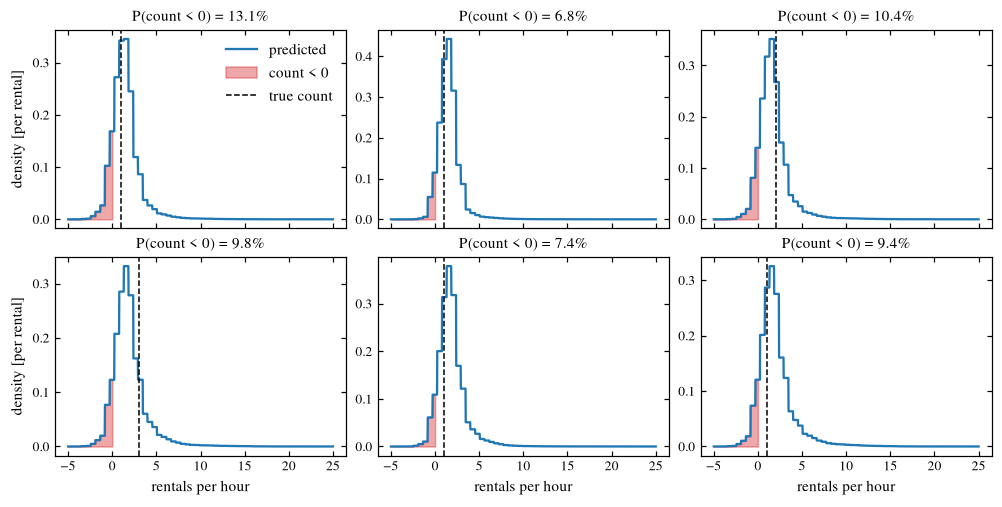

In [5]:
counts = np.linspace(-5, 25, 1201)
lowest = np.argsort(median)[:6]
fig, axes = plt.subplots(
    2, 3, figsize=(9, 4.5), sharex=True, layout="constrained"
)
for ax, i in zip(axes.flat, lowest):
    density = dist[i : i + 1].pdf(counts)[0]
    ax.plot(counts, density, label="predicted")
    ax.fill_between(
        counts,
        density,
        where=counts <= 0,
        color="C3",
        alpha=0.4,
        label="count < 0",
    )
    ax.axvline(y_test[i], color="k", ls="--", lw=1, label="true count")
    ax.set_title(f"P(count < 0) = {below_zero[i]:.1%}")
for ax in axes[-1]:
    ax.set_xlabel("rentals per hour")
for ax in axes[:, 0]:
    ax.set_ylabel("density [per rental]")
_ = axes[0, 0].legend()

The figure shows that for these quiet hours, in which one to three bikes
were rented, the predicted density peaks at a count of one or two, and part
of its lower tail spills below zero. No count in the context is below one,
so this mass is on values that cannot occur. Averaged over all test hours,
it is small (0.25%), since most hours have medians far from the floor, but
it reaches 6.8% to 13.1% on these six hours.

## Intervals near the floor

The same spill appears in the intervals. We print the 95% central interval
of the quietest hours, and the fraction of quiet hours whose true count falls
inside it.

In [6]:
inside = (q[:, 0] <= y_test) & (y_test <= q[:, 4])
print(
    pd.DataFrame(
        q[lowest][:, [0, 2, 4]].round(2),
        columns=["2.5%", "median", "97.5%"],
    ).assign(true=y_test[lowest])
)
print(
    f"95% interval coverage: {inside.mean():.1%} over all hours, "
    f"{inside[quiet].mean():.1%} over the {quiet.sum()} quiet hours"
)

   2.5%  median  97.5%  true
0 -0.89    1.31   5.35   1.0
1 -0.46    1.46   4.31   1.0
2 -0.77    1.50   6.07   2.0
3 -0.78    1.64   6.66   3.0
4 -0.57    1.64   5.62   1.0
5 -0.75    1.67   7.17   1.0
95% interval coverage: 96.0% over all hours, 95.6% over the 228 quiet hours


The lower bound of the 95% interval is negative for these hours. Since no
true count lies below zero, we read such an interval as running from zero
(or from the smallest possible count) to its upper bound: clipping the
lower bound changes neither which true counts fall inside it nor its
coverage, which stays close to the nominal 95% on the quiet hours. A model
fit to $\log(1 + y)$ instead puts no mass below zero by construction, and
its quantiles transform back exactly, but we do not pursue it here.

## Spread grows with the level

Counts are noisier when they are larger, as for a Poisson process, where
the standard deviation is the square root of the mean. We measure the
spread of each predicted distribution by half the width of its 68% interval
and plot it against the predicted median.

median in [0, 10):  228 hours, half-width   3.0, ratio to sqrt 1.40
median in [10, 50):  326 hours, half-width   8.9, ratio to sqrt 1.87
median in [50, 200):  678 hours, half-width  26.5, ratio to sqrt 2.38
median in [200, 500):  623 hours, half-width  44.7, ratio to sqrt 2.47
median in [500, inf):  145 hours, half-width  60.4, ratio to sqrt 2.42


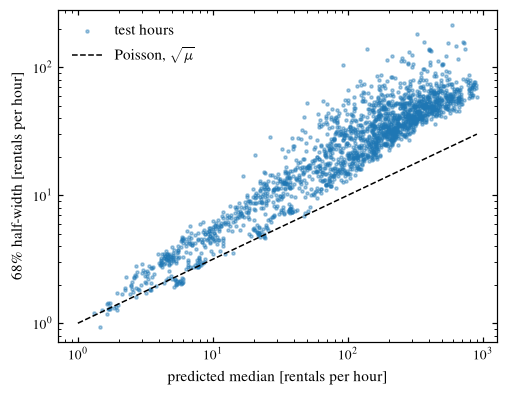

In [7]:
half_width = (q[:, 3] - q[:, 1]) / 2
levels = np.geomspace(1, median.max(), 100)
fig, ax = plt.subplots(figsize=(4.5, 3.5), layout="constrained")
ax.scatter(median, half_width, s=4, alpha=0.4, label="test hours")
ax.plot(levels, np.sqrt(levels), "k--", lw=1, label=r"Poisson, $\sqrt{\mu}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("predicted median [rentals per hour]")
ax.set_ylabel("68% half-width [rentals per hour]")
_ = ax.legend()

ratio = half_width / np.sqrt(median)
for lo, hi in [(0, 10), (10, 50), (50, 200), (200, 500), (500, np.inf)]:
    s = (median >= lo) & (median < hi)
    print(
        f"median in [{lo}, {hi}): {s.sum():4d} hours, half-width "
        f"{np.median(half_width[s]):5.1f}, "
        f"ratio to sqrt {np.median(ratio[s]):.2f}"
    )

The figure shows that the predicted spread grows steadily with the
predicted level, from a few rentals per hour for the quietest hours to tens
for the busiest, without our telling the model anything about counts. The
table under it shows that the spread grows faster than the Poisson
expectation: the median ratio of the half-width to $\sqrt{\mu}$ rises from
1.40 below a median of 10 to between 2.38 and 2.47 above 50. We suspect
this is because hours with the same features still differ in ways the
features do not record (e.g., events in the city), which adds to the
Poisson noise.

## Wine quality: seven integer levels

The `wine_quality` dataset scores red and white wines on an integer scale
from their chemistry. Only seven scores occur, from 3 to 9, and most wines
score 5, 6 or 7. We encode the `wine_color` column as 0 (red) or 1 (white),
and use a random 4,000 wines as the context and the remaining 2,497 as the
test set.

In [8]:
Xw, yw = datasets.load_dataset("wine_quality", return_X_y=True)
Xw = encode(Xw)
rows = rng.permutation(len(Xw))
train_w, test_w = rows[:4000], rows[4000:]
yw_test = yw[test_w].astype(int)
print(pd.Series(yw).value_counts().sort_index().to_dict())

wine = lazy.LazyModel(random_state=SEED)
wine.fit(Xw.iloc[train_w], yw[train_w])
dist_w = wine.predict_distribution(Xw.iloc[test_w])

{3.0: 30, 4.0: 216, 5.0: 2138, 6.0: 2836, 7.0: 1079, 8.0: 193, 9.0: 5}


The predicted distribution is a density, but it is not spread smoothly
between the integers. To see how much of it lies on the integers, we
measure the probability within 0.1 of one. We then compute the probability
of each level $k$ by integrating the density over $[k - 0.5, k + 0.5]$, as
$P(k) = F(k + 0.5) - F(k - 0.5)$ from the exact `cdf`, and compare the
average of these probabilities over the test wines with the observed
frequency of each level.

In [9]:
k = np.arange(3, 10)
near = dist_w.cdf(np.sort(np.r_[k - 0.1, k + 0.1]))
print(
    f"mean probability within 0.1 of an integer: "
    f"{np.diff(near, axis=1)[:, ::2].sum(axis=1).mean():.1%}"
)

cdf_edges = dist_w.cdf(np.arange(2.5, 10.0))  # F(k - 0.5), ..., F(9.5)
p_level = np.diff(cdf_edges, axis=1)  # P(k), shape (n_wines, 7)
print(f"mean probability on [2.5, 9.5]: {p_level.sum(axis=1).mean():.2%}")
pd.DataFrame(
    {
        "predicted": p_level.mean(axis=0),
        "observed": [(yw_test == level).mean() for level in k],
    },
    index=pd.Index(k, name="quality"),
).round(3).T

mean probability within 0.1 of an integer: 94.9%
mean probability on [2.5, 9.5]: 99.94%


quality,3,4,5,6,7,8,9
predicted,0.002,0.029,0.351,0.427,0.161,0.029,0.001
observed,0.003,0.033,0.334,0.432,0.165,0.031,0.001


The model appears to have learned that the target is discrete: on average,
94.9% of each predicted distribution lies within 0.1 of an integer, in
narrow spikes at the scores the context contains. Almost all of it lies
between 2.5 and 9.5, and the average probability of each level matches its
observed frequency to within 0.02. The most probable level is the true score
for 67.6% of the test wines (printed below). The figure then shows the level
probabilities and the CDF of six random test wines.

most probable level is the true score for 67.6% of wines


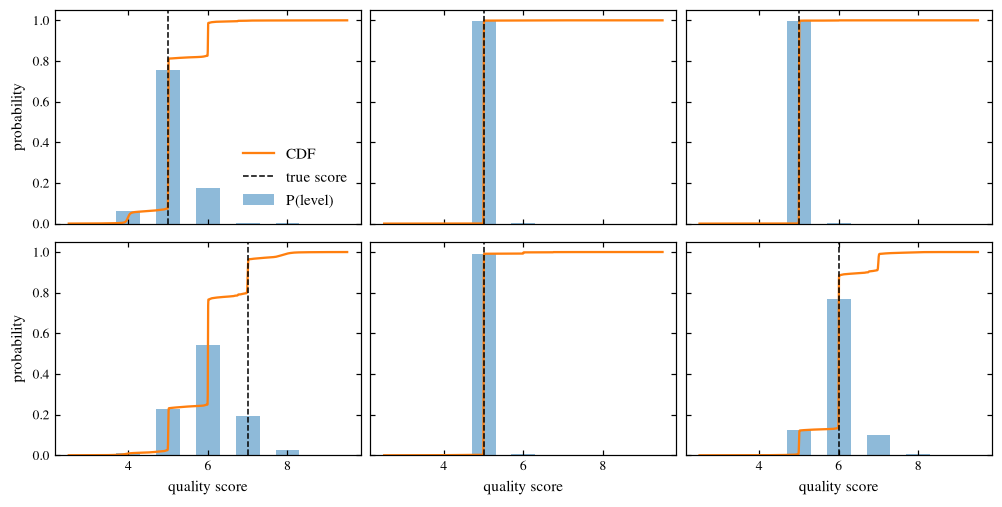

In [10]:
print(
    f"most probable level is the true score for "
    f"{(k[p_level.argmax(axis=1)] == yw_test).mean():.1%} of wines"
)

some = rng.choice(len(test_w), size=6, replace=False)
grid = np.linspace(2.5, 9.5, 1401)
fig, axes = plt.subplots(
    2, 3, figsize=(9, 4.5), sharex=True, sharey=True, layout="constrained"
)
for ax, i in zip(axes.flat, some):
    ax.bar(k, p_level[i], width=0.6, color="C0", alpha=0.5, label="P(level)")
    ax.plot(grid, dist_w[i : i + 1].cdf(grid)[0], "C1", label="CDF")
    ax.axvline(yw_test[i], color="k", ls="--", lw=1, label="true score")
for ax in axes[-1]:
    ax.set_xlabel("quality score")
for ax in axes[:, 0]:
    ax.set_ylabel("probability")
_ = axes[0, 0].legend()

The figure shows that each CDF is a staircase that rises almost only at the
integers, and the bars give the height of each step. Three of these wines
put almost all of their probability on a score of 5, while the others spread
it over three or four neighboring scores.

## The PIT of a discrete target

The probability integral transform (PIT) of a true value $y$ is $F(y)$, the
predicted probability below it. For calibrated distributions of a
continuous target, the PIT is uniform between 0 and 1 (see
[Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html#discrete-targets-and-the-pit)).
For a discrete target, $F$ jumps at $y$ from $F(y - 0.5)$ to $F(y + 0.5)$,
and the plain PIT lands at one place inside that jump, so it is not
uniform even when the distributions are calibrated. The randomized PIT
instead draws a value uniformly within the jump,
$F(y - 0.5) + u\,[F(y + 0.5) - F(y - 0.5)]$ with $u$ uniform on $[0, 1]$,
which is uniform for calibrated distributions of a discrete target. We
compute both with the `pit` method of the distribution, which evaluates the
CDF of each wine at its own value (here the true score and the
half-integers on either side of it), and test each against a uniform
distribution with `metrics.pit_statistics`.

In [11]:
pit = dist_w.pit(yw_test)  # F(y)
low = dist_w.pit(yw_test - 0.5)  # F(y - 0.5)
high = dist_w.pit(yw_test + 0.5)  # F(y + 0.5)
pit_random = low + rng.uniform(size=len(test_w)) * (high - low)

position = (pit - low) / (high - low)
print(
    f"median position of the plain PIT within the jump: "
    f"{np.median(position):.2f}"
)
pd.DataFrame(
    {
        "plain PIT": metrics.pit_statistics(pit),
        "randomized PIT": metrics.pit_statistics(pit_random),
    }
).loc[["pit_ks", "pit_ks_pvalue", "pit_cvm", "pit_kl"]].T

median position of the plain PIT within the jump: 0.52


,pit_ks,pit_ks_pvalue,pit_cvm,pit_kl
plain PIT,0.105768,8.888855e-25,8.084315,0.101017
randomized PIT,0.020354,2.487434e-01,0.211319,0.002381


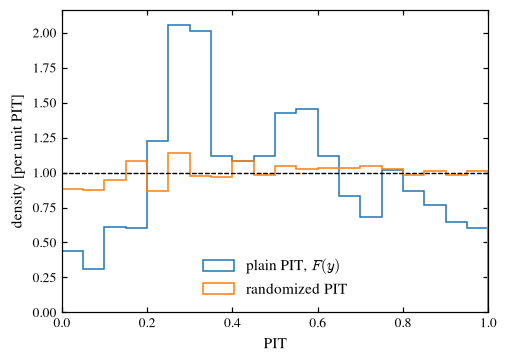

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 3.2), layout="constrained")
plotting.plot_pit(pit, ax=ax, label="plain PIT, $F(y)$")
plotting.plot_pit(pit_random, ax=ax, label="randomized PIT")
ax.set_ylabel("density [per unit PIT]")
_ = ax.legend(loc="lower center")

The figure shows the histograms of the two PITs for the 2,497 test wines,
with the dashed line marking a uniform distribution. The plain PIT has too
few wines near 0 and 1 and a lumpy excess in between, highest near 0.3,
which would usually be read as distributions that are too wide. This is an
artifact of the discrete target: the plain PIT sits near the middle of the
jump at the true score (0.52 of the way up it, in the median), and therefore
rarely reaches the ends of $[0, 1]$. The randomized PIT is consistent with a
uniform distribution, with a Kolmogorov-Smirnov $p$-value of 0.25 (vs.
$9 \times 10^{-25}$ for the plain PIT), so we find no evidence that the
predicted distributions are miscalibrated at this sample size.

For the next steps, we suggest the following pages:

- [Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html):
  discrete targets and the PIT, and categorical columns.
- [From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html):
  the native distributions, their `cdf`, and the metrics.
- [Skewed targets](https://lazy-tfm.readthedocs.io/en/latest/tutorials/skewed_targets.html):
  targets with long tails.